# Notebook: Conceptos Clave de Machine Learning
Este notebook cubre varios conceptos fundamentales de Machine Learning, con secciones que incluyen descripción, explicación, ejercicio, solución y código documentado sobre un dataset sintético.

## Creación de Dataset Sintético
Generamos un dataset con variables categóricas, ordinales y numéricas, y una variable objetivo binaria.

In [53]:
import numpy as np
import pandas as pd

np.random.seed(123)
n = 200
df = pd.DataFrame({
    'CatA': np.random.choice(['X', 'Y', 'Z'], size=n),
    'CatB': np.random.choice(['A', 'B'], size=n),
    'Ord': np.random.choice(['Low', 'Medium', 'High'], size=n),
    'Num1': np.random.randn(n),
    'Num2': np.random.rand(n) * 100,
    'target': np.random.choice([0, 1], size=n)
})
df.head()

,CatA,CatB,Ord,Num1,Num2,target
0,Z,B,Medium,1.501997,26.328104,1
1,Y,B,High,-0.188256,35.506513,0
2,Z,A,High,-0.740112,95.414397,1
3,Z,A,Low,-1.160529,46.113787,1
4,X,A,Medium,0.131529,68.489147,0


### 1. Codificación One-Hot
**Descripción:** Transformación de variables categóricas en variables binarias.

**Explicación:** Se crea una columna por cada nivel de la categoría y se asigna 1 o 0.

**Ejercicio:** Aplica codificación One-Hot a `CatA` y `CatB`.

**Solución:**

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# One-Hot Encoding
df_ohe = pd.get_dummies(df[['CatA', 'CatB']], drop_first=True)

In [66]:
df_ohe.head()

,CatA_Y,CatA_Z,CatB_B
0,False,True,True
1,True,False,True
2,False,True,False
3,False,True,False
4,False,False,False


In [70]:
# One-Hot Encoding
df_ohe = pd.get_dummies(df[['CatA', 'CatB']])
df_ohe.head()

,CatA_X,CatA_Y,CatA_Z,CatB_A,CatB_B
0,False,False,True,False,True
1,False,True,False,False,True
2,False,False,True,True,False
3,False,False,True,True,False
4,True,False,False,True,False


In [71]:
X = pd.concat([df_ohe, df[['Num1', 'Num2']]], axis=1)
y = df['target']

In [72]:
# Entrenamiento de modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)
model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(X_train, y_train)

print('One-Hot Encoding completo. Score:', model.score(X_test, y_test))

One-Hot Encoding completo. Score: 0.44


### 2. Codificación de Etiquetas
**Descripción:** Asigna un entero a cada nivel de la categoría.

**Explicación:** OrdinalEncoder transforma categorías en 0,1,2,...

**Ejercicio:** Aplica codificación de etiquetas a todas las variables categóricas.

**Solución:**

In [73]:
df.head()

,CatA,CatB,Ord,Num1,Num2,target
0,Z,B,Medium,1.501997,26.328104,1
1,Y,B,High,-0.188256,35.506513,0
2,Z,A,High,-0.740112,95.414397,1
3,Z,A,Low,-1.160529,46.113787,1
4,X,A,Medium,0.131529,68.489147,0


In [34]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
df_enc = df.copy()
df_enc[['CatA', 'CatB', 'Ord']] = encoder.fit_transform(df[['CatA', 'CatB', 'Ord']])

In [35]:
df_enc.head()

,CatA,CatB,Ord,Num1,Num2,target
0,2.0,1.0,2.0,1.501997,26.328104,1
1,1.0,1.0,0.0,-0.188256,35.506513,0
2,2.0,0.0,0.0,-0.740112,95.414397,1
3,2.0,0.0,1.0,-1.160529,46.113787,1
4,0.0,0.0,2.0,0.131529,68.489147,0


In [74]:
X = df_enc.drop('target', axis=1)
y = df_enc['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=12345)
model.fit(X_train, y_train)
print('Codificación de etiquetas completa. Score:', model.score(X_test, y_test))

Codificación de etiquetas completa. Score: 0.44


### 3. Escalado Numérico (StandardScaler)
**Descripción:** Normaliza las variables numéricas para media 0 varianza 1.

**Explicación:** `StandardScaler` ajusta media y desviación estándar.

**Ejercicio:** Escala `Num1` y `Num2`.

**Solución:**

In [37]:
from sklearn.preprocessing import StandardScaler

numeric = ['Num1', 'Num2']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric] = scaler.fit_transform(df[numeric])
df_scaled.head()

,CatA,CatB,Ord,Num1,Num2,target
0,Z,B,Medium,1.588194,-0.887760,1
1,Y,B,High,-0.102731,-0.575473,0
2,Z,A,High,-0.654806,1.462840,1
3,Z,A,Low,-1.075390,-0.214570,1
4,X,A,Medium,0.217181,0.546732,0


### 4. Exactitud para el Árbol de Decisión
**Descripción:** Medida de aciertos sobre datos de validación.

**Explicación:** `accuracy_score` muestra proporción de predicciones correctas.

**Ejercicio:** Entrena un árbol y calcula exactitud.

**Solución:**

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df.drop('target', axis=1).select_dtypes(include=[np.number])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)



In [39]:
tree = DecisionTreeClassifier(random_state=12345)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.36


### 5. Prueba de Consistencia
**Descripción:** Comparación con predicción constante.

**Explicación:** Frecuencia de clases vs. modelo vs. baseline constante.

**Ejercicio:** Mide frecuencia y compara con modelo constante.

**Solución:**

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Frecuencia de clases predicha
freq = pd.Series(tree.predict(X_test)).value_counts(normalize=True)
print('Frecuencia:', freq)

Frecuencia: 0    0.6
1    0.4
Name: proportion, dtype: float64


In [41]:
# Baseline constante
baseline_pred = pd.Series(0, index=y)
print('Baseline Accuracy:', accuracy_score(y, baseline_pred))



Baseline Accuracy: 0.535


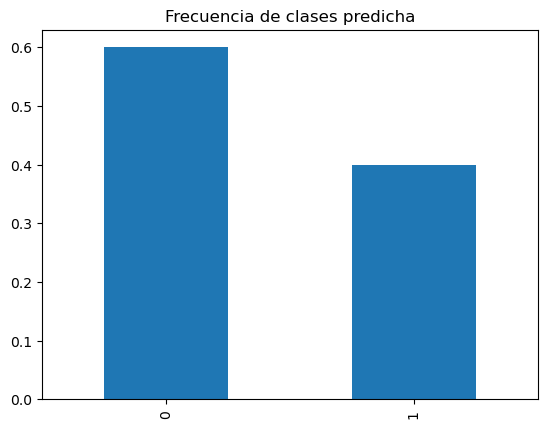

In [42]:
# Gráfico
freq.plot(kind='bar', title='Frecuencia de clases predicha')
plt.show()

### 6. Equilibrio y Desequilibrio de Clases
Exploramos matriz de confusión, recall, precisión y F1.

#### 6.1 Matriz de Confusión

In [43]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 8 10]
 [22 10]]


#### 6.2 Recall

In [44]:
from sklearn.metrics import recall_score
print('Recall:', recall_score(y_test, y_pred))

Recall: 0.3125


#### 6.3 Precisión

In [45]:
from sklearn.metrics import precision_score
print('Precision:', precision_score(y_test, y_pred))

Precision: 0.5


#### 6.4 Valor F1

In [46]:
from sklearn.metrics import f1_score
print('F1 Score:', f1_score(y_test, y_pred))

F1 Score: 0.38461538461538464


### 7. Manejo del Desbalanceo de Clases

In [47]:
# 7.1 Manejo del desequilibrio de clases usando pesos en Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# 1. Inicializar el modelo
#    - class_weight='balanced': ajusta automáticamente los pesos inversamente
#      proporcionales a la frecuencia de cada clase en los datos de entrenamiento.
#    - solver='liblinear'   : optimizador eficiente para conjuntos de datos pequeños
#    - random_state=12345    : garantiza reproducibilidad de los resultados
model_bal = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    random_state=12345
)

# 2. Entrenar el modelo con los datos de entrenamiento
#    X_train: características de entrenamiento
#    y_train: etiquetas de entrenamiento
model_bal.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
#    X_test: características de prueba
y_pred = model_bal.predict(X_test)

# 4. Calcular la puntuación F1
#    F1 combina precision y recall en una métrica balanceada,
#    útil cuando las clases están desbalanceadas.
f1 = f1_score(y_test, y_pred)

# 5. Mostrar resultado
print(f'F1 con clase balanceada: {f1:.3f}')


F1 con clase balanceada: 0.633


In [48]:
# 7.2 Manejo del desequilibrio de clases mediante sobremuestreo

import pandas as pd
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# 1. Reconstruir el DataFrame de entrenamiento uniendo características y etiqueta
#    X_train: DataFrame con las variables predictoras de entrenamiento
#    y_train: Series con la variable objetivo de entrenamiento
df_train = pd.concat([X_train, y_train.rename('target')], axis=1)

# 2. Separar la clase mayoritaria y minoritaria
major = df_train[df_train['target'] == 0]  # Ejemplares de la clase 0 (mayoría)
minor = df_train[df_train['target'] == 1]  # Ejemplares de la clase 1 (minoría)

# 3. Realizar sobremuestreo de la clase minoritaria
#    - replace=True: permite muestreo con reemplazo
#    - n_samples=len(major): igualar el número de muestras de la clase mayoritaria
#    - random_state=12345: para reproducibilidad
minor_upsampled = resample(
    minor,
    replace=True,
    n_samples=len(major),
    random_state=12345
)

# 4. Concatenar las clases original y sobremuestreada
train_up = pd.concat([major, minor_upsampled])

# 5. Separar nuevamente en características (X_up) y etiqueta (y_up)
X_up = train_up.drop('target', axis=1)
y_up = train_up['target']

# 6. Crear y entrenar un modelo de regresión logística
model_up = LogisticRegression(
    solver='liblinear',  # recomendado para datasets pequeños
    random_state=12345
)
model_up.fit(X_up, y_up)

# 7. Evaluar el modelo en el conjunto de prueba original
y_pred_up = model_up.predict(X_test)
f1_up = f1_score(y_test, y_pred_up)

# 8. Imprimir la métrica F1 resultante
print(f'F1 tras sobremuestreo: {f1_up:.3f}')


F1 tras sobremuestreo: 0.610


In [49]:
# 7.3 Manejo del desequilibrio de clases mediante submuestreo

from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Partimos de los mismos DataFrames:
# - major: clase mayoritaria (target == 0)
# - minor: clase minoritaria (target == 1)

# 1. Realizar submuestreo de la clase mayoritaria
#    - replace=False: muestreo sin reemplazo
#    - n_samples=len(minor): reducir el número de muestras de la clase mayoritaria
#      para igualar la cantidad de la clase minoritaria
#    - random_state=12345: reproducibilidad
major_down = resample(
    major,
    replace=False,
    n_samples=len(minor),
    random_state=12345
)

# 2. Reconstruir el conjunto de entrenamiento combinando la clase minoritaria original
#    con la versión reducida de la clase mayoritaria
train_down = pd.concat([major_down, minor])

# 3. Separar características y etiqueta tras el submuestreo
X_down = train_down.drop('target', axis=1)
y_down = train_down['target']

# 4. Inicializar y entrenar el modelo de regresión logística
model_down = LogisticRegression(
    solver='liblinear',  # optimizador adecuado para datasets pequeños
    random_state=12345
)
model_down.fit(X_down, y_down)

# 5. Predecir sobre el conjunto de prueba original
y_pred_down = model_down.predict(X_test)

# 6. Calcular y mostrar la métrica F1
f1_down = f1_score(y_test, y_pred_down)
print(f'F1 tras submuestreo: {f1_down:.3f}')


F1 tras submuestreo: 0.586


In [51]:
# Supongamos que 'ohe_cols' es la lista de columnas resultantes
# tras pd.get_dummies(df[['CatA','CatB']], drop_first=True) usada en X_train.

# 1. Codificación One-Hot sobre el test
test_ohe = pd.get_dummies(df_test[['CatA','CatB']], drop_first=True)

# 2. Alineación de columnas: rellenar con ceros las que faltan y desechar las extra
test_ohe = test_ohe.reindex(columns=ohe_cols, fill_value=0)

# 3. Reconstruir X_test con numéricas y OHE
X_test_proc = pd.concat([test_ohe, df_test[['Num1','Num2']].reset_index(drop=True)], axis=1)

# 4. Ahora sí:
probs = model.predict_proba(X_test_proc)[:, 1]
for thresh in np.arange(0, 1, 0.2):
    preds = probs > thresh
    print(f'Threshold {thresh:.1f} -> '
          f'Precision: {precision_score(y_test, preds):.2f}, '
          f'Recall:    {recall_score(y_test, preds):.2f}')


NameError: name 'df_test' is not defined

### 8. Métricas de Regresión
Creamos un dataset de regresión sintético y evaluamos MSE, RMSE, R2 y MAE.

In [52]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Dataset
X_reg, y_reg = make_regression(n_samples=200, n_features=3, noise=10.0, random_state=12345)
X_tr, X_va, y_tr, y_va = train_test_split(X_reg, y_reg, test_size=0.25, random_state=12345)

lr = LinearRegression()
lr.fit(X_tr, y_tr)
y_pred = lr.predict(X_va)

print('MSE:', mean_squared_error(y_va, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_va, y_pred)))
print('R2:', r2_score(y_va, y_pred))
print('MAE:', mean_absolute_error(y_va, y_pred))

MSE: 127.21562127979877
RMSE: 11.278990259761676
R2: 0.9866867819019742
MAE: 8.311035996083262
